## Pearson and Spearman Correlation Analysis

### Objective

This EDA step evaluates how the four structural features—`lcd`, `pld`, `void_fraction`, and `surface_area_m2g`—are associated with CO₂ uptake at five pressures.

For each feature–target pair, the analysis will determine:

* The direction of the relationship: positive or negative.
* The strength of the relationship.
* Whether the relationship changes in strength or direction with pressure.
* Whether the relationship appears linear or monotonic but nonlinear.

| Method               | What It Measures                                                                                                 |
| -------------------- | ---------------------------------------------------------------------------------------------------------------- |
| Pearson correlation  | Strength and direction of a linear relationship                                                                  |
| Spearman correlation | Strength and direction of a monotonic relationship based on ranked values; it can detect some nonlinear patterns |

Correlation coefficients range from -1 to +1:

* Values close to +1 indicate a strong positive relationship.
* Values close to -1 indicate a strong negative relationship.
* Values close to 0 indicate a weak or undetected relationship.

For example, the analysis will test whether the association between `surface_area_m2g` and CO₂ uptake becomes stronger, weaker, or changes direction as pressure increases.



**The main scientific hypothesis is:**

Different structural features may be associated with CO₂ uptake at different pressures.

This hypothesis will be tested rather than assumed.

### Expected Outcomes

The analysis will produce:

* A Pearson correlation table containing four features × five pressure targets.
* A Spearman correlation table with the same structure.
* Identification of the strongest positive and negative correlations at each pressure.
* Comparison of correlation strength and direction across the five pressures.
* Identification of relationships where Spearman is notably stronger than Pearson, suggesting a potentially monotonic but nonlinear pattern that requires visualization.
* A shortlist of feature–target relationships for further investigation using scatterplots or hexbin plots.

### Interpretation Limitations

Correlation analysis does not prove:

* That a structural feature causes CO₂ uptake to increase or decrease.
* That a feature will be important in a multivariable machine-learning model.
* That a stronger Spearman correlation confirms a nonlinear relationship; it only identifies a pattern that should be investigated visually.
* That a near-zero correlation means the feature is useless, because the relationship may be non-monotonic or depend on interactions with other features.
              ======================================================

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Load Data
data = pd.read_csv('/home/susan/mof-co2-adsorption/data/processed/data_clean_v2')
# Copy dataframe
df= data.copy()
print(df.columns)
print("="*30)
print()



Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       'CO2_uptake_2.5bar_molkg'],
      dtype='object')



## Step 1 — Prepare and Validate the Data



In [ ]:
#1A. Define the features and targets
# Store the four structural features used in the relationship analysis.
feature_columns = ["lcd", "pld", "void_fraction", "surface_area_m2g"]

# Store the five CO2-uptake targets in increasing pressure order.
target_columns = ["CO2_uptake_0.01bar_molkg", "CO2_uptake_0.05bar_molkg", "CO2_uptake_0.1bar_molkg", "CO2_uptake_0.5bar_molkg", "CO2_uptake_2.5bar_molkg"]

# Combine the feature and target column names into one list.
correlation_columns = feature_columns + target_columns

# Select only the columns required for correlation analysis.
correlation_data = df[correlation_columns].copy()

# Display the first five records to confirm that the correct columns were selected.
display(correlation_data.head())


,lcd,pld,void_fraction,surface_area_m2g,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
0,11.75,10.75,0.795539,3676.3,0.022406,0.073552,0.225851,0.885221,4.33307
1,4.75,3.25,0.388986,580.7,0.173407,0.925813,1.806490,4.779010,7.34618
2,4.75,3.75,0.307505,377.6,0.651164,2.129830,2.817220,3.909470,4.93236
3,9.25,8.25,0.731919,3399.2,0.031321,0.143123,0.332034,1.756380,6.91190
4,3.75,2.75,0.323803,85.2,0.144024,0.698367,1.402230,2.694200,4.15694


In [ ]:
# 1B. Check the dataset dimensions
# Display the number of rows and columns in the correlation dataset.
print("Correlation data shape:", correlation_data.shape)
# Display the number of rows and columns in the correlation dataset.
print("Correlation data shape:", correlation_data.shape)

# Display the total number of records.
print("Number of MOFs:", correlation_data.shape[0])

# Display the total number of selected variables.
print("Number of variables:", correlation_data.shape[1])


Correlation data shape: (31234, 9)
Correlation data shape: (31234, 9)
Number of MOFs: 31234
Number of variables: 9


In [ ]:
# Display the data type of each selected feature and target.
display(correlation_data.dtypes.to_frame(name="data_type"))
# Find any selected columns that are not numeric.
non_numeric_columns = correlation_data.select_dtypes(
    exclude="number"
).columns.tolist()
print(non_numeric_columns)

,data_type
lcd,float64
pld,float64
void_fraction,float64
surface_area_m2g,float64
CO2_uptake_0.01bar_molkg,float64
CO2_uptake_0.05bar_molkg,float64
CO2_uptake_0.1bar_molkg,float64
CO2_uptake_0.5bar_molkg,float64
CO2_uptake_2.5bar_molkg,float64


[]


=================================================
We check for infinite values because a column can be float64 and still contain:

inf (positive infinity)
-inf (negative infinity)

These are different from missing values (NaN). They may result from calculations such as division by zero. Pearson and Spearman correlations require finite numerical values; infinity can make the correlation result invalid or return NaN.

## Decision Before Calculating Correlation

Proceed only if:

* The shape is (31234, 9).
* All nine columns are numeric.
* Missing-value counts are zero.
* Infinite-value counts are zero.

===========================================================

In [ ]:
# Check every value and count infinite values in each column.
infinite_count = pd.Series(
    np.isinf(correlation_data.to_numpy()).sum(axis=0),
    index=correlation_data.columns,
    name="infinite_count",
)

# Display the number of infinite values in each column.
display(infinite_count.to_frame())

,infinite_count
lcd,0
pld,0
void_fraction,0
surface_area_m2g,0
CO2_uptake_0.01bar_molkg,0
CO2_uptake_0.05bar_molkg,0
CO2_uptake_0.1bar_molkg,0
CO2_uptake_0.5bar_molkg,0
CO2_uptake_2.5bar_molkg,0


In [ ]:
# Calculate Pearson correlations among all four features and five targets.
pearson_matrix = correlation_data.corr(method="pearson")

# Extract only the correlations between the four features and five targets.
pearson_feature_target = pearson_matrix.loc[
    feature_columns,
    target_columns
]

# Display the feature–target correlation table rounded to three decimals.
display(pearson_feature_target.round(3))

,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
lcd,-0.391,-0.480,-0.509,-0.505,-0.196
pld,-0.381,-0.474,-0.506,-0.519,-0.234
void_fraction,-0.411,-0.446,-0.436,-0.283,0.210
surface_area_m2g,-0.468,-0.547,-0.559,-0.457,0.066


In [ ]:
# Step 3 — Calculate Spearman Correlations
# Calculate Spearman correlations among all selected features and targets.
spearman_matrix = correlation_data.corr(method="spearman")

# Extract only the correlations between the four features and five CO₂ targets.
spearman_feature_target = spearman_matrix.loc[
    feature_columns,
    target_columns
]



In [ ]:

# Build a side-by-side comparison: for each pressure, show Pearson then Spearman.
comparison_table = pd.concat(
    {
        "Pearson": pearson_feature_target,
        "Spearman": spearman_feature_target,
    },
    axis=1,
).swaplevel(0, 1, axis=1)

# Keep pressure order and place the two methods next to each other for each pressure.
ordered_columns = []
for target in target_columns:
    ordered_columns.extend([(target, "Pearson"), (target, "Spearman")])

comparison_table = comparison_table.loc[:, ordered_columns]
comparison_table.columns = pd.MultiIndex.from_tuples(
    comparison_table.columns,
    names=["pressure", "method"],
)

# Display rounded comparison table.
display(comparison_table.round(3))

pressure         CO2_uptake_0.01bar_molkg          CO2_uptake_0.05bar_molkg  \
method                            Pearson Spearman                  Pearson   
lcd                                -0.391   -0.667                   -0.480   
pld                                -0.381   -0.670                   -0.474   
void_fraction                      -0.411   -0.640                   -0.446   
surface_area_m2g                   -0.468   -0.664                   -0.547   

pressure                  CO2_uptake_0.1bar_molkg           \
method           Spearman                 Pearson Spearman   
lcd                -0.665                  -0.509   -0.659   
pld                -0.667                  -0.506   -0.660   
void_fraction      -0.633                  -0.436   -0.622   
surface_area_m2g   -0.658                  -0.559   -0.647   

pressure         CO2_uptake_0.5bar_molkg          CO2_uptake_2.5bar_molkg  \
method                           Pearson Spearman                 Pearson   
lcd                               -0.505   -0.566                  -0.196   
pld                               -0.519   -0.572                  -0.234   
void_fraction                     -0.283   -0.504                   0.210   
surface_area_m2g                  -0.457   -0.517                   0.066   

pressure                   
method           Spearman  
lcd                -0.091  
pld                -0.128  
void_fraction       0.006  
surface_area_m2g    0.052

## Summary Matrix: Pearson vs. Spearman Coefficients

| Structural Feature | 0.01 bar (P / S) | 0.05 bar (P / S) | 0.1 bar (P / S) | 0.5 bar (P / S) | 2.5 bar (P / S) |
| --- | --- | --- | --- | --- | --- |
| **lcd** (Largest Cavity Diameter) | -0.391 / -0.667 | -0.480 / -0.665 | -0.509 / -0.659 | -0.505 / -0.566 | -0.196 / -0.091 |
| **pld** (Pore Limiting Diameter) | -0.381 / -0.670 | -0.474 / -0.667 | -0.506 / -0.660 | -0.519 / -0.572 | -0.234 / -0.128 |
| **void_fraction** (Internal Space) | -0.411 / -0.640 | -0.446 / -0.633 | -0.436 / -0.622 | -0.283 / -0.504 | 0.210 / 0.006 |
| **surface_area_m2g** (Available Area) | -0.468 / -0.664 | -0.547 / -0.658 | -0.559 / -0.647 | -0.457 / -0.517 | 0.066 / 0.052 |

*Note: (P / S) denotes (Pearson correlation / Spearman correlation).*

---

### 1. Structural Curvature at Low Pressures (0.01 to 0.1 bar)

- **Mathematical reality:** Spearman magnitudes are consistently much stronger than Pearson magnitudes.
- **Physical phenomenon:** The pore-size relationship (`lcd`, `pld`) with CO2 uptake is strongly monotonic but nonlinear in this pressure regime.
- **Uptake mechanism:** As pore diameters shrink, CO2 uptake does not increase linearly; it rises sharply. Overlapping potential fields in narrow pores can create deeper adsorption wells, which favor stronger capture under low-pressure conditions.

### 2. Linear Transition Phase (0.1 to 0.5 bar)

- **Mathematical reality:** Pearson coefficients strengthen and move closer to Spearman, while Spearman remains relatively stable.
- **Physical phenomenon:** The low-pressure curvature begins to flatten toward a more proportional trend.
- **Uptake mechanism:** Highly favorable narrow-pore sites fill first. With increasing pressure, additional uptake increasingly occurs in wider or less selective pore space, producing a more linear aggregate response.

### 3. High-Pressure Mechanism Shift (2.5 bar)

- **Mathematical reality:** Size-based negative correlations (`lcd`, `pld`) weaken substantially, while volume-related metrics move toward weak positive association.
- **Physical phenomenon:** The structural-restriction signal becomes less dominant at high pressure.
- **Uptake mechanism:** The process transitions from affinity-dominated filling to capacity/space-dominated packing. At 2.5 bar, accessible pore volume (for example, `void_fraction`) contributes more to total loading than strict narrow-pore selectivity.

## Scatterplot and Hexbin Analysis

### Objective

This EDA step visually examines how each structural feature—`lcd`, `pld`, `void_fraction`, and `surface_area_m2g`—relates to CO₂ uptake at each pressure.

### Advantages of the Plots

- Scatterplots show individual observations, outliers, and the overall relationship pattern.
- Hexbin plots group nearby observations into colored regions that represent data density.
- Hexbin plots are especially useful for this dataset because plotting 31,234 points can create excessive overlap in a regular scatterplot.

### Expected Outcome

The plots will help us:

- Confirm whether the correlation patterns are visible in the data.
- Identify potentially nonlinear feature–uptake relationships.
- Detect dense regions, clusters, gaps, and unusual observations.
- Determine whether relationships change across pressure levels.
- Select patterns that may require further analysis.

These two-variable plots do not directly prove feature interactions. Feature interactions will require additional plots or modeling methods involving multiple features.

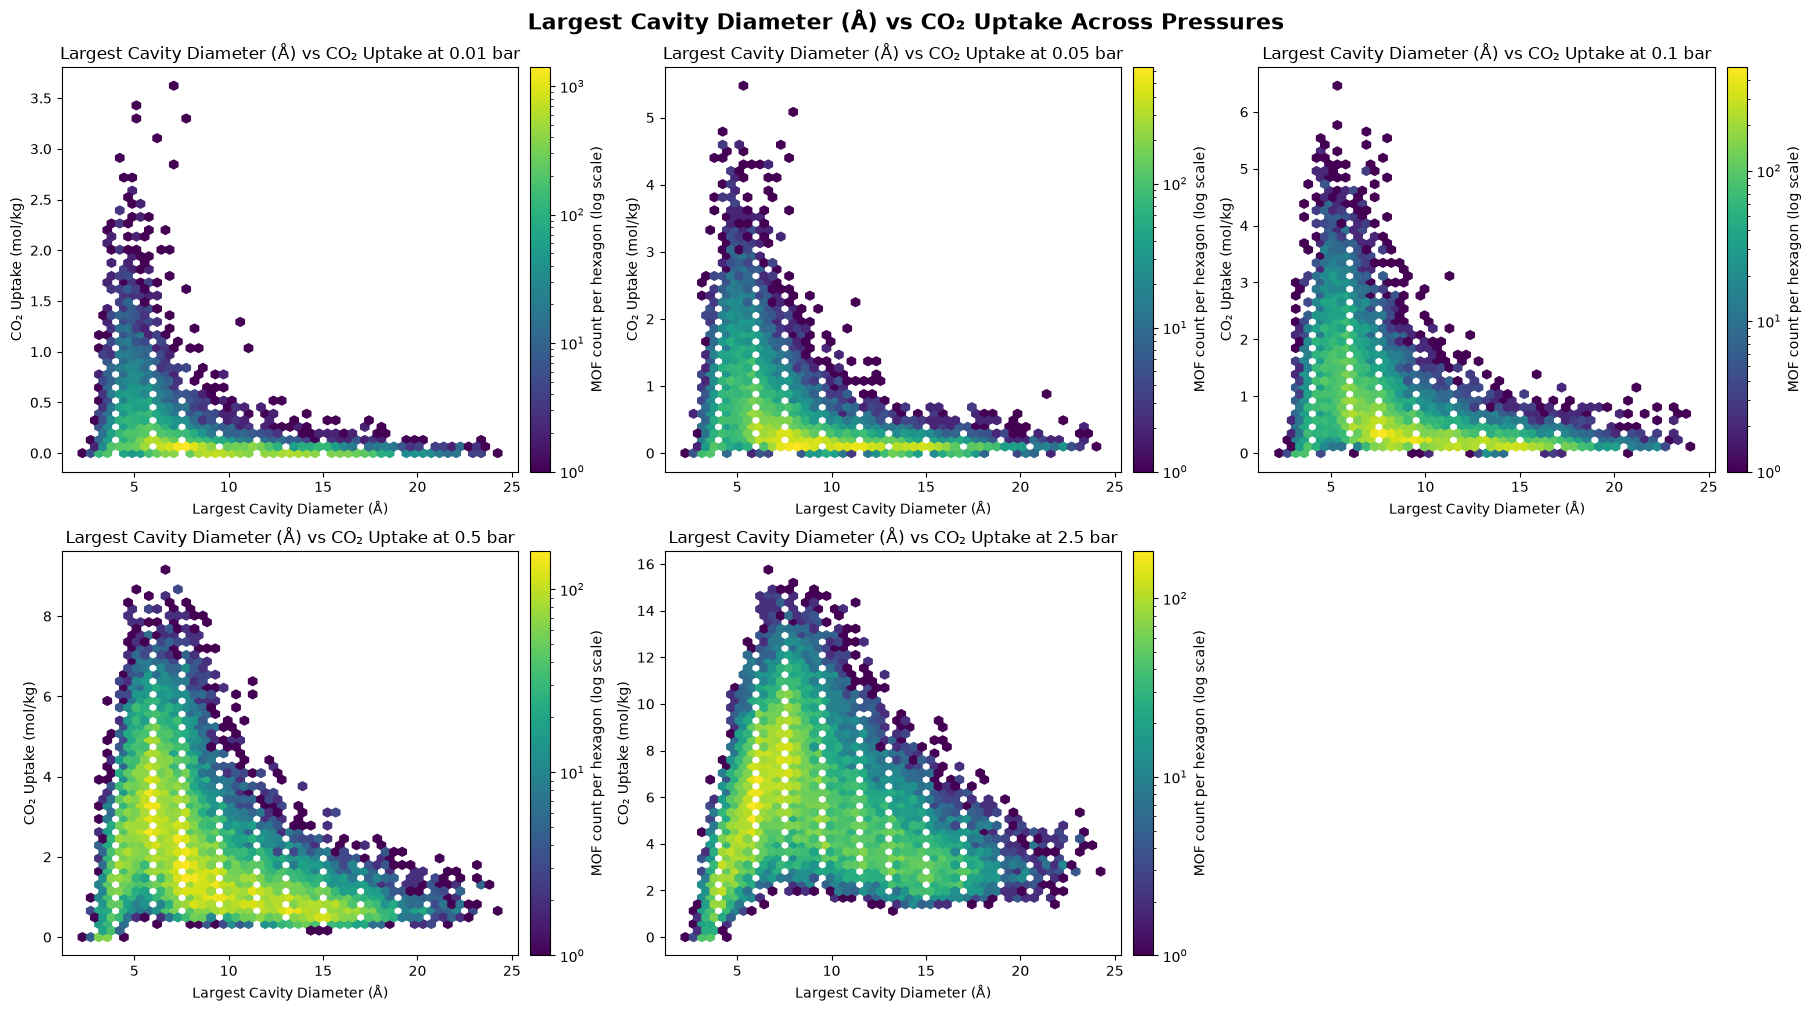

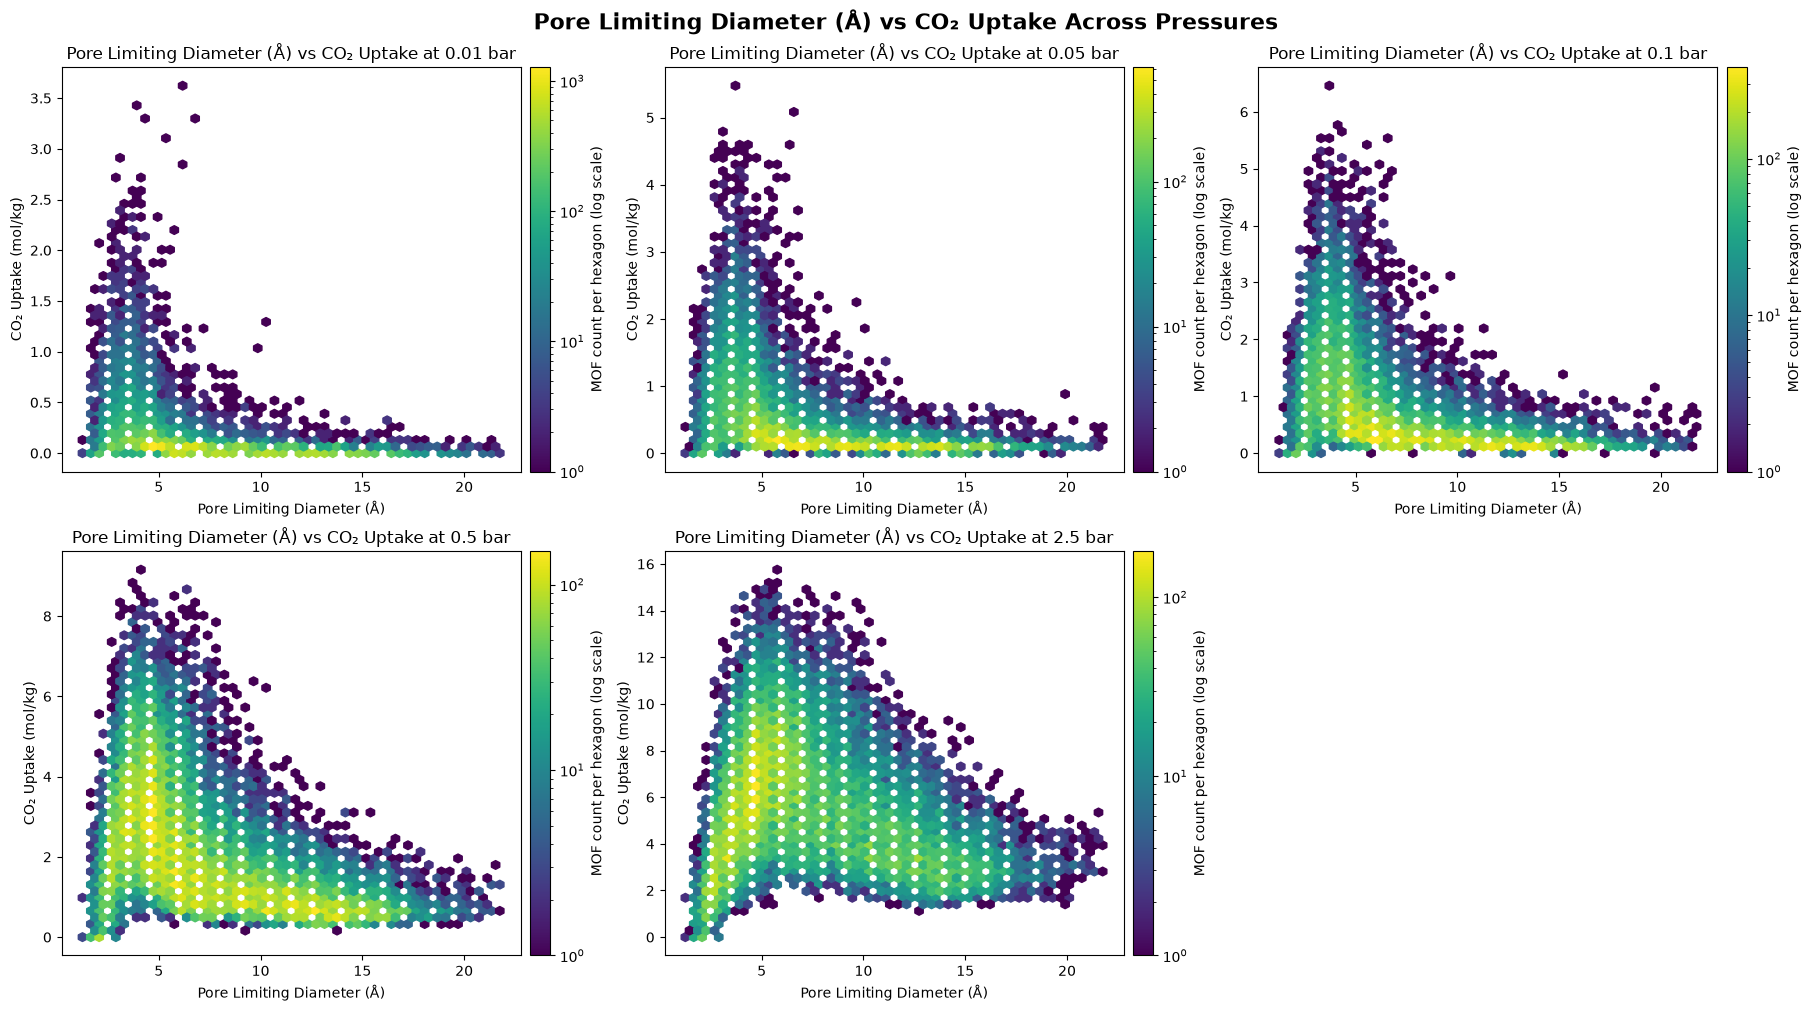

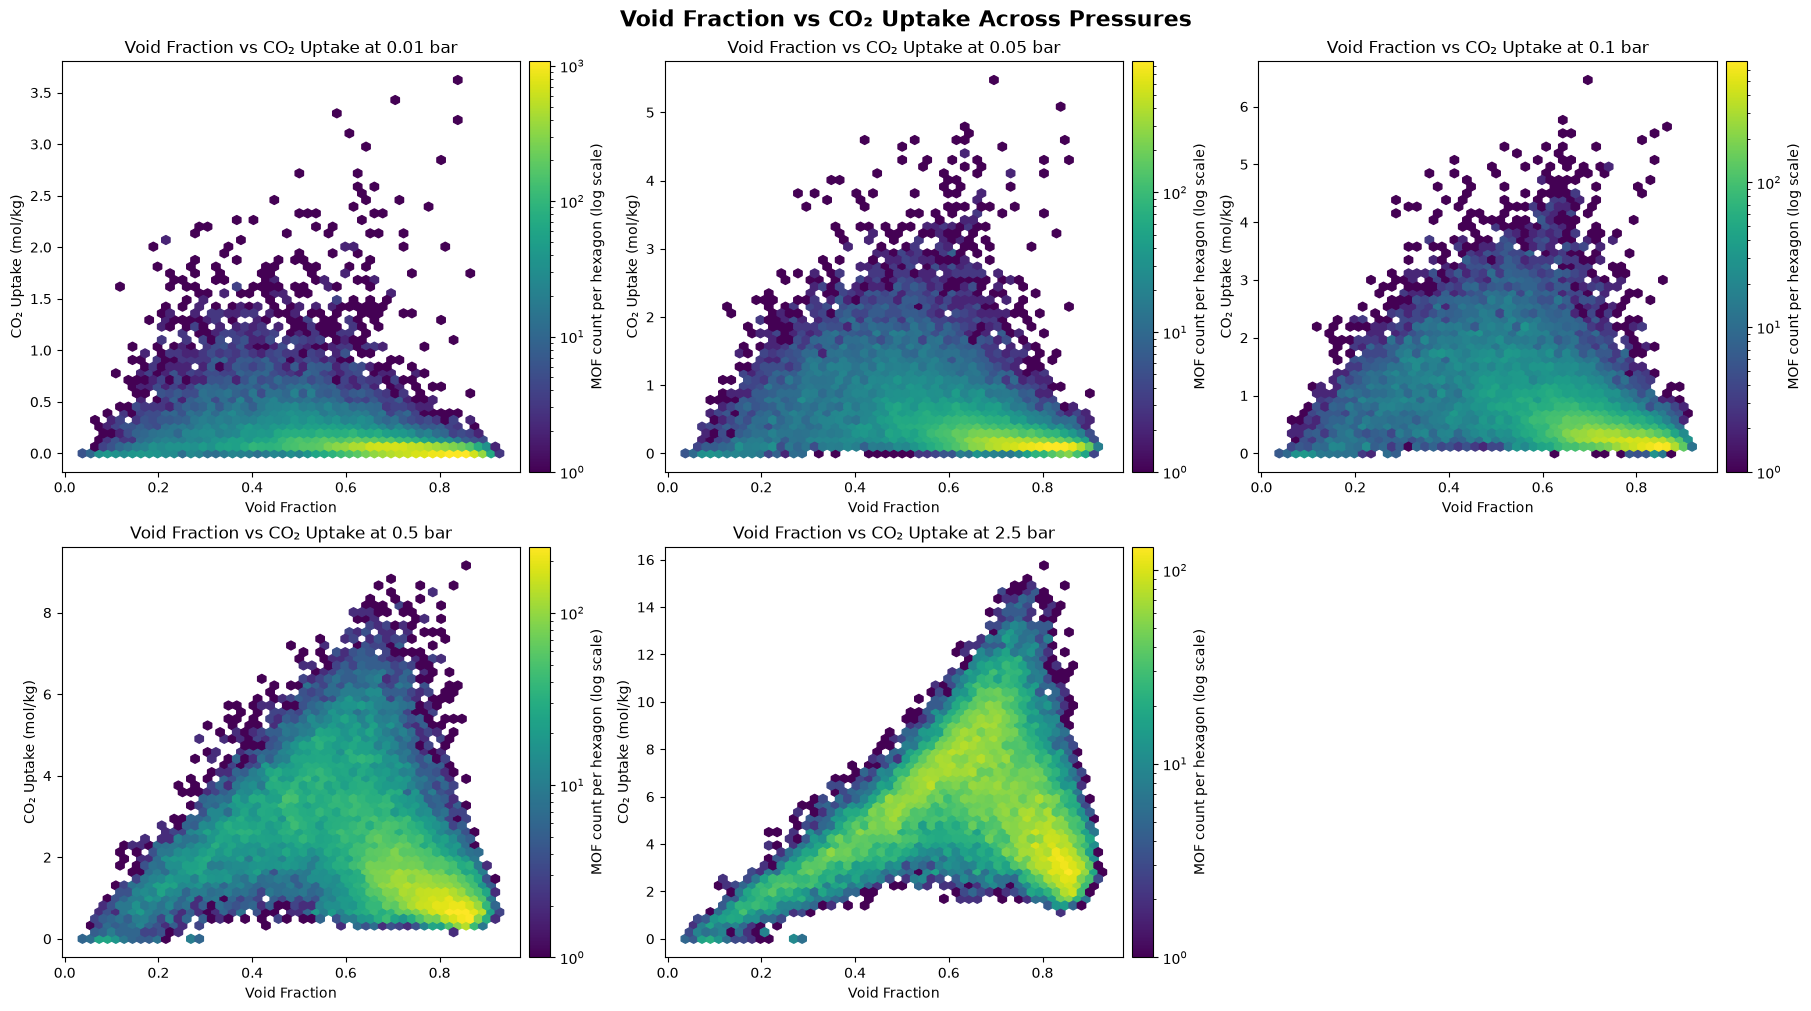

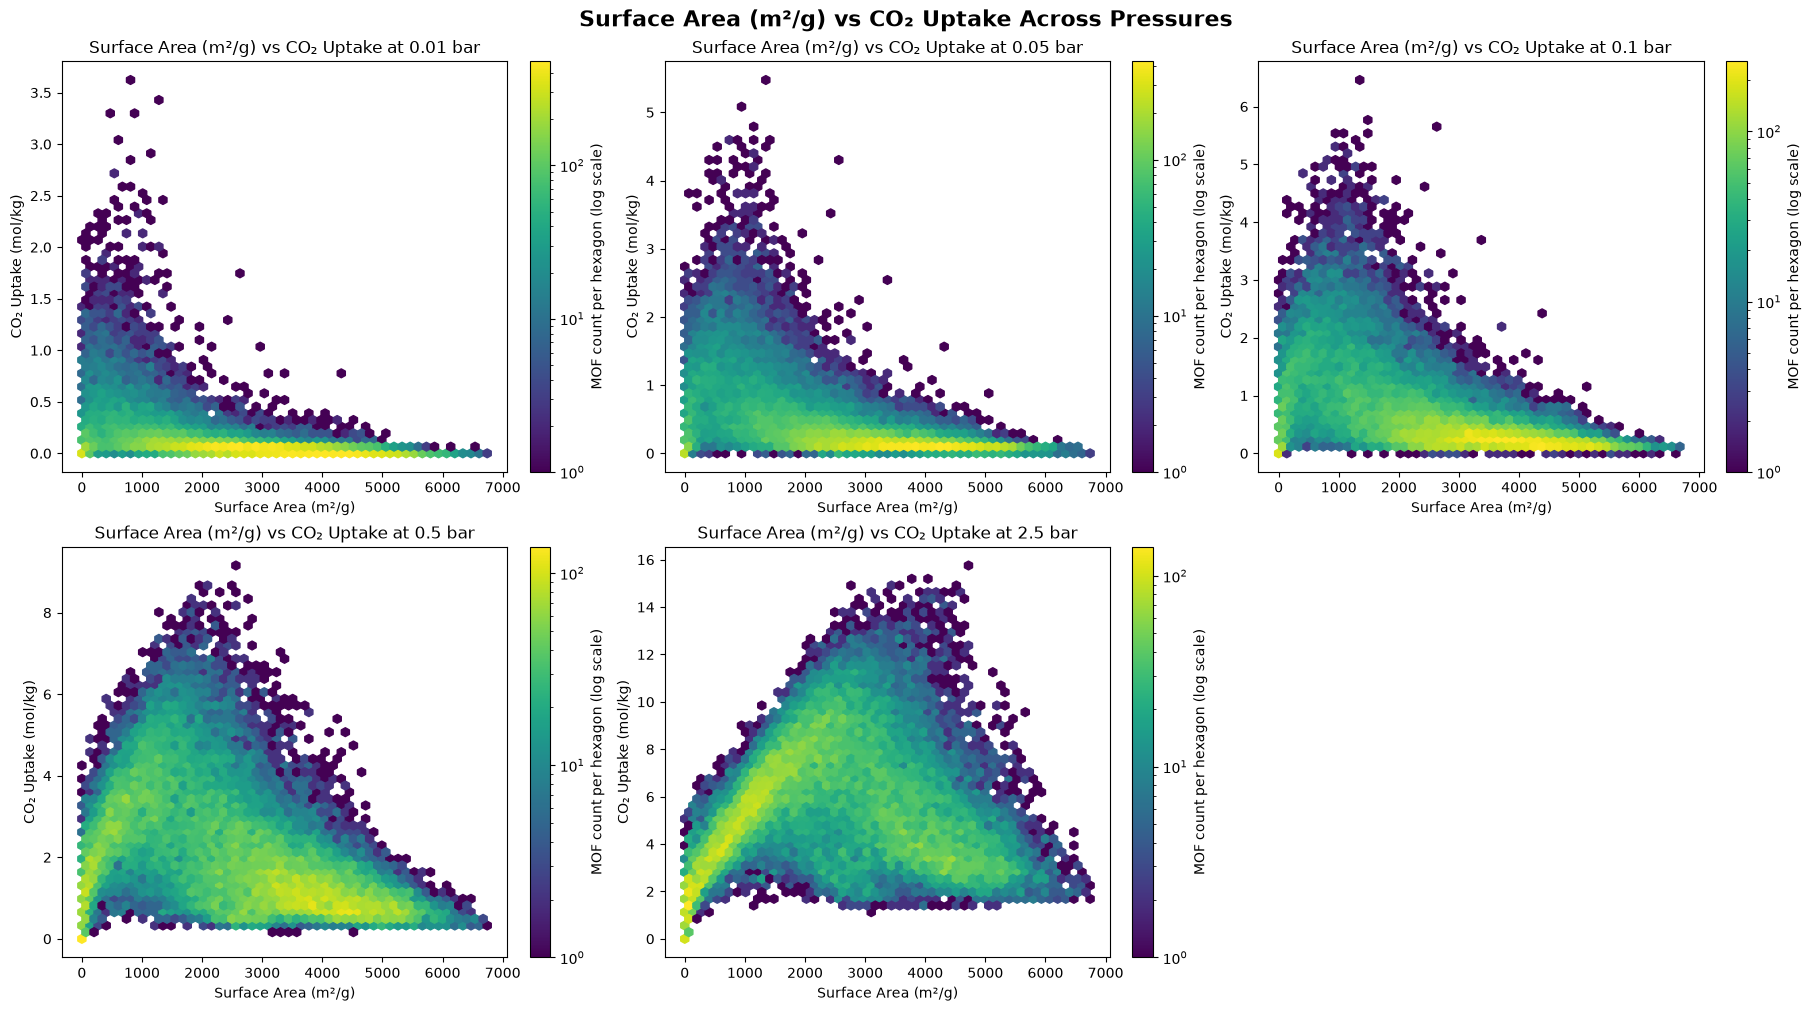

In [ ]:
# Store the four features and their readable labels.
features = {
    "lcd": "Largest Cavity Diameter (Å)",
    "pld": "Pore Limiting Diameter (Å)",
    "void_fraction": "Void Fraction",
    "surface_area_m2g": "Surface Area (m²/g)",
}

# Store the five CO₂-uptake targets and their pressure labels.
pressure_targets = {
    "CO2_uptake_0.01bar_molkg": "0.01 bar",
    "CO2_uptake_0.05bar_molkg": "0.05 bar",
    "CO2_uptake_0.1bar_molkg": "0.1 bar",
    "CO2_uptake_0.5bar_molkg": "0.5 bar",
    "CO2_uptake_2.5bar_molkg": "2.5 bar",
}

# Define a reusable function for plotting one feature at five pressures.
def plot_feature_across_pressures(dataframe, feature, feature_label):
    """Create five hexbin plots for one structural feature against CO₂ uptake at five pressures."""

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(18, 10),
        constrained_layout=True,
    )
    axes = axes.flatten()

    for ax, (target, pressure) in zip(axes, pressure_targets.items()):
        hexbin_plot = ax.hexbin(
            dataframe[feature],
            dataframe[target],
            gridsize=50,
            cmap="viridis",
            mincnt=1,
            bins="log",
          
        )
        colorbar = fig.colorbar(hexbin_plot, ax=ax, pad=0.02)
        colorbar.set_label("MOF count per hexagon (log scale)")
        ax.set_xlabel(feature_label)
        ax.set_ylabel("CO₂ Uptake (mol/kg)")
        ax.set_title(f"{feature_label} vs CO₂ Uptake at {pressure}")

    axes[-1].axis("off")
    fig.suptitle(
        f"{feature_label} vs CO₂ Uptake Across Pressures",
        fontsize=16,
        fontweight="bold",
    )
    plt.show()

# Create one separate figure for each feature.
for feature, feature_label in features.items():
    plot_feature_across_pressures(
        dataframe=correlation_data,
        feature=feature,
        feature_label=feature_label,
    )

### Interpretation of LCD and PLD Scatter Hexbin Plot
Relatively smaller LCD and PLD values are associated with the highest CO₂ uptake across all studied pressures. As LCD and PLD increase, the upper range of CO₂ uptake decreases sharply, indicating a nonlinear negative relationship between pore diameter and maximum adsorption performance. CO₂ uptake also increases systematically with pressure across the investigated pore-size ranges.

## Scientific Reason 
Smaller LCD and PLD values can enhance CO₂ adsorption because the interaction fields from nearby pore walls overlap, strengthening CO₂ confinement (Palakkal & Pillai, 2020). As pore diameter increases, this confinement becomes weaker, which can reduce uptake, particularly at low pressure. Increasing pressure promotes further pore filling and therefore raises the total CO₂ uptake (Wilmer et al., 2012).

`References`
`Palakkal, A. S., & Pillai, R. S. (2020). Tuning the ultra-micropore size of fluorinated MOFs for CO₂ capture from flue gases by advanced computational methods. The Journal of Physical Chemistry C, 124(31), 16975–16989.`
`Wilmer, C. E., Farha, O. K., Bae, Y.-S., Hupp, J. T., & Snurr, R. Q. (2012). Structure–property relationships of porous materials for carbon dioxide separation and capture. Energy & Environmental Science, 5, 9849–9856.`

=====================================================================


### Interpretation of Void Fraction Scatter Hexbin Plot
## What is Void Fraction?

    Void fraction (also known as porosity) is the ratio of empty space (pore volume) to the total volume of the material. It ranges from 0 to 1:0 means the material is completely solid rock with no internal pores.1 means the material is entirely empty space (pure vacuum/air).

#### Void Fraction vs.CO2 Uptake Analysis    

*1. Triangular Pattern*

    CO₂ uptake generally increases as void fraction rises toward an intermediate-to-high range (approximately 0.6–0.8). At the highest void fractions, the maximum uptake decreases, producing a triangular pattern.

* Scientific reason:*
    This pattern suggests a balance between available pore space and CO₂–framework interactions. Low void fraction provides insufficient space for storing CO₂, while very high void fraction can provide weaker interaction with the pore walls. Intermediate-to-high void fractions provide a better balance between storage space and adsorption strength (Wilmer et al., 2012).

*2. Effect of Increasing Pressure*

    At low pressure, many MOFs show almost zero CO₂ uptake. As pressure increases, the lower boundary of the plots rises, especially within the intermediate void-fraction range.

    Scientific reason:
    At low pressure, CO₂ uptake depends strongly on the attraction between CO₂ molecules and the framework. At higher pressure, increased gas-phase chemical potential promotes pore filling, making available pore space more important and increasing uptake (Liu et al., 2012).

*References*

    Liu, J., Thallapally, P. K., McGrail, B. P., Brown, D. R., & Liu, J. (2012). Progress in adsorption-based CO₂ capture by metal–organic frameworks. Chemical Society Reviews, 41(6), 2308–2322. https://doi.org/10.1039/C1CS15221A
    Wilmer, C. E., Farha, O. K., Bae, Y.-S., Hupp, J. T., & Snurr, R. Q. (2012). Structure–property relationships of porous materials for carbon dioxide separation and capture. Energy & Environmental Science, 5, 9849–9856. https://doi.org/10.1039/C2EE23201D

    ==========================================================================

## Surface Area vs. CO₂ Uptake

### 1. Shifting Optimal Surface Area

**Interpretation:**
At low pressures (0.01–0.1 bar), the highest CO₂ uptake occurs mainly at surface areas around 1,000–2,000 m²/g. As pressure increases to 0.5 and 2.5 bar, the high-uptake region shifts toward larger surface areas, approximately 2,000–4,500 m²/g.

**Scientific reason:**
At low pressure, adsorption depends strongly on the attraction between CO₂ and the framework. Moderate surface areas with narrower pores can provide stronger CO₂ confinement. At higher pressure, more adsorption sites and pore space become occupied, making larger accessible surface areas more useful for increasing capacity (Wilmer et al., 2012; Palakkal & Pillai, 2020).

### 2. Decrease at Very High Surface Area

**Interpretation:**
Above approximately 5,000–6,000 m²/g, the maximum CO₂ uptake decreases across all studied pressures.

**Scientific reason:**
A very high surface area does not always produce high CO₂ uptake. It may be associated with larger pores and higher void fraction, which can weaken CO₂ confinement. Therefore, uptake decreases after the best balance between accessible surface area, pore space, and adsorption strength is exceeded (Wilmer et al., 2012).

### 3. Effect of Increasing Pressure

**Interpretation:**
As pressure increases, CO₂ uptake rises across the studied surface-area range. At 2.5 bar, most MOFs between approximately 1,000 and 4,000 m²/g show measurable uptake.

**Scientific reason:**
Increasing pressure raises the gas-phase chemical potential, allowing more CO₂ molecules to occupy adsorption sites and fill accessible pore space. This increases CO₂ uptake, although interactions between CO₂ and the framework remain important (Wilmer et al., 2012).

## References

* Palakkal, A. S., & Pillai, R. S. (2020). Tuning the ultra-micropore size of fluorinated MOFs for CO₂ capture from flue gases by advanced computational methods. *The Journal of Physical Chemistry C, 124*(31), 16975–16989. https://doi.org/10.1021/acs.jpcc.0c03633

* Wilmer, C. E., Farha, O. K., Bae, Y.-S., Hupp, J. T., & Snurr, R. Q. (2012). Structure–property relationships of porous materials for carbon dioxide separation and capture. *Energy & Environmental Science, 5*, 9849–9856. https://doi.org/10.1039/C2EE23201D
